[ Pytorch DL MODEL 실습 ]

- 데이터셋 : iris.csv
- 학습방법 : 지도학습 + 분류 ==> 2진분류


[1] 모듈로딩 <hr>

In [226]:
## 모듈로딩
import pandas as pd  # 데이터 모듈
import numpy as np

import torch         
# tensor 및 기본 함수 모듈   
import torch.nn as nn
# 인공신경망 관련 모듈
import torch.nn.functional as F
# 인공신경망 관련 함수
import torch.optim as optim
# 최적화 모듈

from sklearn.model_selection import train_test_split
# 학습용 데이터셋 관련 함수

In [227]:
irisDF = pd.DataFrame(pd.read_csv('../_data/iris.csv', skipfooter=50, engine='python'))

[2] 데이터 로딩 및 확인 <hr> 

In [228]:
irisDF.head()
irisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  100 non-null    float64
 1   sepal.width   100 non-null    float64
 2   petal.length  100 non-null    float64
 3   petal.width   100 non-null    float64
 4   variety       100 non-null    object 
dtypes: float64(4), object(1)
memory usage: 4.0+ KB


In [229]:
irisDF.variety.unique()

array(['Setosa', 'Versicolor'], dtype=object)

In [230]:
irisDF.variety = irisDF.variety.replace({'Setosa':0, 'Versicolor':1})

C:\Users\kdt\AppData\Local\Temp\ipykernel_37796\3857719111.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  irisDF.variety = irisDF.variety.replace({'Setosa':0, 'Versicolor':1})


In [231]:
irisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  100 non-null    float64
 1   sepal.width   100 non-null    float64
 2   petal.length  100 non-null    float64
 3   petal.width   100 non-null    float64
 4   variety       100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


In [232]:
featureDF = irisDF[irisDF.columns[:-1]] # feature 4개
targetSR = irisDF[irisDF.columns[4]]  # 



In [233]:

X_train, X_test, y_train, y_test = train_test_split(
    featureDF, targetSR, train_size= 0.8, stratify=targetSR, random_state=42)

In [234]:
print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D (80, 4) / X_test => 2D, (20, 4)
y_train => 1D (80,), / y_test => 1D, (20,)


[4] 모델 클래스 설계 및 구현 <hr>

In [235]:
""" 
데이터셋 iris: 피쳐 4, 타겟 1. 타겟은 범주형 3가지
학습 방법은 : 범주형이므로 분류 - 
구현알고리즘: 인공신경망 DNN
	  입력        퍼셉트론    활성화함수
입력층 4(피쳐4)   12(퍼셉트론)  RELU
은닉충  12          8 		RELU
출력층  8	    	3		
"""

class Iris_Model(nn.Module):
    # 인스턴스 초기화 및 생성 메서드
    def __init__(self):
        super().__init__() #부모(nn.Module)의 init 생성
        print('__init__()')
        self.in_layer=nn.Linear(4, 12)  #input, output
        self.hd_layer1=nn.Linear(12, 8)        # 히든1
        self.out_layer=nn.Linear(8, 1)

    # 순전파 학습 메서드 
    def forward(self, data):
        #- 입력층
        out=self.in_layer(data)      # data * weight + b
        out=F.relu(out)              # AF(data * weight + b) 결과물
                                     # 은닉으로 넘겨줌.
        #- 은닉층
        out=self.hd_layer1(out)      # out * weight + b
        out=F.relu(out)              # AF(out * weight + b) 결과물    
                
        #- 출력층 : 회귀로 결과 그라드 반환
        out=self.out_layer(out)      # out * weight + b

        return F.sigmoid(out)
               

In [236]:
iModel = Iris_Model()
iModel

__init__()


Iris_Model(
  (in_layer): Linear(in_features=4, out_features=12, bias=True)
  (hd_layer1): Linear(in_features=12, out_features=8, bias=True)
  (out_layer): Linear(in_features=8, out_features=1, bias=True)
)

In [237]:
featureDF = irisDF[irisDF.columns[:-1]] # feature 4개
targetSR = irisDF[irisDF.columns[4]]  # 

featureTs = torch.FloatTensor(featureDF.values)
targetTs = torch.FloatTensor(targetSR)

X_train, X_test, y_train, y_test = train_test_split(
    featureTs, targetTs, train_size= 0.8, stratify=targetSR, random_state=42)


print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D torch.Size([80, 4]) / X_test => 2D, torch.Size([20, 4])
y_train => 1D torch.Size([80]), / y_test => 1D, torch.Size([20])


In [238]:
data = torch.FloatTensor([[1. , 3.2, 1.9, 2.6]])

In [239]:

# 확률 변환 (Softmax 적용)
probabilities = torch.softmax(iModel(data), dim=1)

# 가장 높은 확률을 가진 클래스 선택
predicted_class = torch.argmax(probabilities, dim=1)

# 결과 출력
print(f"예측된 클래스: {predicted_class.item()}")

예측된 클래스: 0


[5] 학습 준비<hr>

In [240]:
## [5-1] 학습 관련 설정들
EPOCH = 1000                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 80                                      # DS를 학습량 만큼 나눈 사이즈
ITERATION = int(X_train.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCH}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {ITERATION}")
      

DEVICE : cpu, EPOCHS : 1000, BATCH_SIZE : 80 ITERATION: 1


In [241]:
# [5-2] 학습 관련 인스턴스들
MODEL  = Iris_Model()                           #학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters())      #최적화 즉, 경사하강법 알고리즘으로 W, b의 값 개신
LOSS_FN = nn.BCELoss()                          #


__init__()


In [242]:
# # 학습함수
# def training():
#     #학습 모드 설정
#     MODEL.train()
    
#     #에포크 : DS 처음부터 ~ 끝가지 학습
#     for epoch in range(EPOCH):
        
#         E_LOSS = 0
#         for i in range(ITERATION):
#             start = i*BATCH_SIZE
#             end = start + BATCH_SIZE
            
#             #nadrray ==> tensor 변환
#             # 처음부터 텐서로 데이터 가르기를 하면 추가 변환이 필요없다.
#             # x = torch.FloatTensor(X_train.values[start:end])
#             # y = torch.FloatTensor(y_train.values[start:end])
            
#             #가중치 기울기 0 초기화
#             OPTIMIZER.zero_grad()
            
#             #학습 진행
#             # pre_y = MODEL(x)
#             pre_y = MODEL(X_train)
            
#             # 손실 계산
#             # loss = LOSS_FN(pre_y, y.reshape(-1,1))
#             loss = LOSS_FN(pre_y, y_train.reshape(-1,1))
            
#             #역전파 진행
#             loss.backward()
            
#             #가중치/절편 업데이트
#             OPTIMIZER.step()
            
#             E_LOSS += loss.item()
            
#         print(f"[EPOCH = {epoch}], LOSS {E_LOSS/ITERATION}")
#     return loss

In [243]:
# 학습함수
def training():
    #학습 모드 설정
    MODEL.train()

    E_LOSS = 0
    for i in range(ITERATION):
        start = i*BATCH_SIZE
        end = start + BATCH_SIZE
        
        #nadrray ==> tensor 변환
        # 처음부터 텐서로 데이터 가르기를 하면 추가 변환이 필요없다.
        # x = torch.FloatTensor(X_train.values[start:end])
        # y = torch.FloatTensor(y_train.values[start:end])
        
        #가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()
        
        #학습 진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_train)
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_train.reshape(-1,1))
        
        #역전파 진행
        loss.backward()
        
        #가중치/절편 업데이트
        OPTIMIZER.step()
        
        E_LOSS += loss.item()
        
    # print(f"[EPOCH = {epoch}], LOSS {E_LOSS/ITERATION}")
    return loss

In [244]:
training()

tensor(0.6865, grad_fn=<BinaryCrossEntropyBackward0>)

In [245]:
## 검증함수
## 검증용 데이터셋으로 모델 검증
## 학습 지속여부 결정 기준이 됨
## -----
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 검증용 데이터셋 => 텐서화
        # ndarray  ==> tensor 변환
        # x = torch.FloatTensor(X_test.values)
        # y = torch.FloatTensor(y_test.values)
        
        #검증진행
        # pre_y = MODEL(x)
        pre_y = MODEL(X_test)
        
        # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1,1))
        loss = LOSS_FN(pre_y, y_test.reshape(-1,1))
        
    return loss
        
        
        

In [246]:
evaluate()

tensor(0.6831)

In [247]:
# 에포크 : DS 처음부터 ~ 끝까지 학습
LOSS_HIST = {'Train':[], 'Valid':[]}

#에포크 단위 학습/검증 진행
for epoch in range(EPOCH):
    trainLoss = training()
    validLoss = evaluate()
    
    LOSS_HIST['Train'].append(trainLoss)
    LOSS_HIST['Valid'].append(validLoss)
    
    print(f"\nEPOCH[{epoch}/{EPOCH}]-------------")
    print(f" - TRAIN_LOSS {trainLoss:.5f}")
    print(f" - VALID_LOSS {validLoss:.5f}")
    


EPOCH[0/1000]-------------
 - TRAIN_LOSS 0.68155
 - VALID_LOSS 0.67809

EPOCH[1/1000]-------------
 - TRAIN_LOSS 0.67663
 - VALID_LOSS 0.67313

EPOCH[2/1000]-------------
 - TRAIN_LOSS 0.67176
 - VALID_LOSS 0.66823

EPOCH[3/1000]-------------
 - TRAIN_LOSS 0.66697
 - VALID_LOSS 0.66339

EPOCH[4/1000]-------------
 - TRAIN_LOSS 0.66227
 - VALID_LOSS 0.65860

EPOCH[5/1000]-------------
 - TRAIN_LOSS 0.65764
 - VALID_LOSS 0.65389

EPOCH[6/1000]-------------
 - TRAIN_LOSS 0.65309
 - VALID_LOSS 0.64925

EPOCH[7/1000]-------------
 - TRAIN_LOSS 0.64861
 - VALID_LOSS 0.64467

EPOCH[8/1000]-------------
 - TRAIN_LOSS 0.64421
 - VALID_LOSS 0.64020

EPOCH[9/1000]-------------
 - TRAIN_LOSS 0.63987
 - VALID_LOSS 0.63586

EPOCH[10/1000]-------------
 - TRAIN_LOSS 0.63559
 - VALID_LOSS 0.63155

EPOCH[11/1000]-------------
 - TRAIN_LOSS 0.63139
 - VALID_LOSS 0.62732

EPOCH[12/1000]-------------
 - TRAIN_LOSS 0.62726
 - VALID_LOSS 0.62314

EPOCH[13/1000]-------------
 - TRAIN_LOSS 0.62326
 - VALID_L

In [248]:
len(LOSS_HIST['Train'])
len(LOSS_HIST['Valid'])

1000

In [ ]:
xdata = range(EPOCH)
ydata1 = LOSS_HIST['Train']
ydata2 = LOSS_HIST['Valid']
ydata = np.linspace(0,1,1000)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

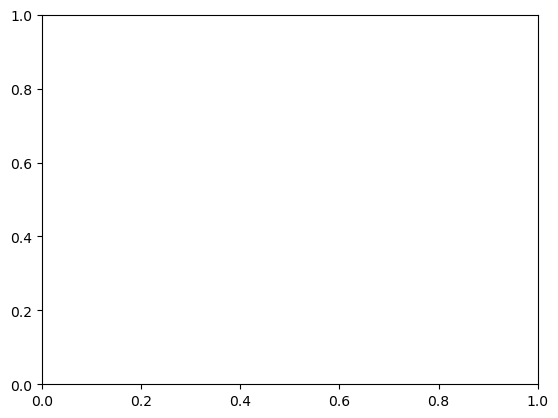

In [252]:
import matplotlib.pyplot as plt

plt.plot(xdata, ydata1, 'r^-', label ='Train')
plt.plot(xdata, ydata2, 'b^-', label ='Valid')

plt.legend()
plt.grid()
plt.show()